In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pylab import mpl
from scipy import signal
from scipy.linalg import toeplitz
from fast_kurtogram import Fast_Kurtogram  # 确保此模块在同一目录下

class BearingFaultAnalyzer:
    """
    滚动轴承故障诊断分析类
    包含: AR预白化、谱峭度图分析(Fast Kurtogram)、包络谱提取与可视化
    """
    def __init__(self, fs=64000, fault_freq=9.7):
        self.fs = fs
        self.fault_freq = fault_freq
        
        # 信号存储
        self.original_signal = None
        self.whitened_signal = None
        
        # Kurtogram 结果存储
        self.Kwav = None
        self.filtered_signal = None
        self.f_low = None
        self.f_high = None
        
        # 包络谱结果存储
        self.env_freqs = None
        self.env_fft = None

        # 初始化绘图设置
        self._setup_plot_style()

    def _setup_plot_style(self):
        """配置全局绘图参数"""
        mpl.rcParams["font.sans-serif"] = ["SimHei"]  # 解决中文显示
        mpl.rcParams["axes.unicode_minus"] = False
        mpl.rcParams["figure.dpi"] = 120

    def load_data(self, filepath, col_name='CH17', max_len=128000):
        """加载 CSV 数据"""
        df = pd.read_csv(filepath, usecols=[col_name])
        self.original_signal = df.values.flatten()[:max_len]
        print(f"✅ 数据加载成功: {filepath} (长度: {len(self.original_signal)} 点)")
        return self

    def apply_ar_prewhitening(self, order=30):
        """执行 AR 预白化消除确定性分量 (如齿轮啮合、工频)"""
        if self.original_signal is None:
            raise ValueError("请先调用 load_data() 加载数据！")
            
        y = self.original_signal
        r = np.correlate(y, y, mode='full')[len(y)-1 : len(y)+order]
        
        try:
            R = toeplitz(r[:-1])
            R += np.eye(order) * 1e-9 # 正则化防止奇异矩阵
            a = np.linalg.solve(R, -r[1:])
            ar_coeffs = np.concatenate(([1], a))
            self.whitened_signal = signal.lfilter(ar_coeffs, [1], y)
            print(f"✅ AR 预白化完成 (阶数: {order})")
        except Exception as e:
            print(f"⚠️ AR 预白化失败，将使用原始信号。原因: {e}")
            self.whitened_signal = y
            
        return self

    def plot_whitening_effect(self, show_points=10000):
        """绘制预白化前后的对比图 (默认只看前 10000 个点，防止图太密)"""
        plt.figure(figsize=(14, 6))
        
        # 原始信号
        plt.subplot(2, 1, 1)
        plt.plot(self.original_signal[:show_points], color='gray', alpha=0.7)
        plt.title('Before Pre-whitening: 原始信号')
        plt.ylabel('Amplitude')
        plt.grid(True, alpha=0.3)
        
        # 白化后信号
        plt.subplot(2, 1, 2)
        plt.plot(self.whitened_signal[:show_points], color='#1f77b4')
        plt.title('After Pre-whitening: 预白化后 (周期性干扰已削弱，突显冲击)')
        plt.xlabel('Samples')
        plt.ylabel('Amplitude')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

    def run_kurtogram_analysis(self, nlevel=4, verbose=False):
        """执行快速谱峭度分析提取最优频带，并计算包络谱"""
        if self.whitened_signal is None:
            print("⚠️ 未执行预白化，将直接对原始信号进行分析...")
            sig_to_process = self.original_signal
        else:
            sig_to_process = self.whitened_signal

        print("--- 开始谱峭度自动检测 ---")
        self.Kwav, Level_w, freq_w, self.filtered_signal, self.f_low, self.f_high = Fast_Kurtogram(
            sig_to_process, nlevel=nlevel, Fs=self.fs, verbose=verbose
        )
        print(f"✅ 检测完成！自动锁定的共振频带: {self.f_low:.2f} Hz - {self.f_high:.2f} Hz")

        # 计算包络谱
        envelope = np.abs(self.filtered_signal)
        env_detrend = envelope - np.mean(envelope)
        self.env_fft = np.abs(np.fft.rfft(env_detrend))
        
        # 根据重采样比例计算有效采样率
        effective_fs = self.fs / (len(sig_to_process) / len(self.filtered_signal))
        self.env_freqs = np.fft.rfftfreq(len(envelope), 1 / effective_fs)
        
        return self

    def plot_comprehensive_results(self, max_env_freq=200, save_path=None, title_suffix=""):
        """绘制三联图：时域、Kurtogram、包络谱"""
        fig, axes = plt.subplots(3, 1, figsize=(12, 10))

        # 1. 时域信号 (使用白化后的信号)
        sig_plot = self.whitened_signal if self.whitened_signal is not None else self.original_signal
        axes[0].plot(sig_plot, color='#7f8c8d', linewidth=0.8, alpha=0.9) 
        axes[0].set_title("分析用信号 (时域)", fontsize=14, fontweight='bold')
        axes[0].set_ylabel("Amplitude", fontsize=12)
        axes[0].grid(True, linestyle='--', alpha=0.4)

        # 2. 谱峭度图 (Kurtogram)
        im = axes[1].imshow(self.Kwav, aspect='auto', cmap='turbo', 
                            extent=[0, self.fs/2, self.Kwav.shape[0], 0], interpolation='bilinear')
        cbar = fig.colorbar(im, ax=axes[1], pad=0.01)
        cbar.set_label('Kurtosis Value', rotation=270, labelpad=20, fontsize=12)
        axes[1].set_title("谱峭度图 (Kurtogram) - 暖色代表冲击特征越强", fontsize=14, fontweight='bold')
        axes[1].set_xlabel("Frequency (Hz)", fontsize=12)
        axes[1].set_ylabel("Level", fontsize=12)

        # 3. 包络谱验证 
        axes[2].plot(self.env_freqs, self.env_fft, color='#2c3e50', linewidth=1.5)
        axes[2].fill_between(self.env_freqs, self.env_fft, color='#3498db', alpha=0.2)

        # 标记故障频率及其倍频
        label_added = False
        for i in range(1, 4):
            if not label_added:
                axes[2].axvline(self.fault_freq*i, color='#e74c3c', linestyle='--', 
                                linewidth=1.5, label=f'Fault Freq & Harmonics ({self.fault_freq}Hz)')
                label_added = True
            else:
                axes[2].axvline(self.fault_freq*i, color='#e74c3c', linestyle='--', linewidth=1.5)

        axes[2].set_xlim(0, max_env_freq)
        axes[2].set_title(f"提取频带 ({self.f_low:.1f}-{self.f_high:.1f} Hz) 的包络谱", fontsize=14, fontweight='bold')
        axes[2].set_xlabel("Frequency (Hz)", fontsize=12)
        axes[2].set_ylabel("Amplitude", fontsize=12)
        axes[2].legend(loc='upper right', framealpha=0.9, edgecolor='gray')
        axes[2].grid(True, linestyle='--', alpha=0.4)

        # 整体去边框
        for ax in axes:
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

        plt.tight_layout()
# 【新增逻辑】：如果传入了保存路径，则保存并关闭；否则直接显示
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight') # dpi=300 保证学术级清晰度
            plt.close(fig)  # 极其重要：释放内存，防止批量出图时卡死
            print(f"📸 图片已保存至: {save_path}")
        else:
            plt.show()



In [7]:
import os
from pathlib import Path
# 假设 BearingFaultAnalyzer 类已经定义好

def batch_process_bearings(data_folder, output_folder, fs=64000, fault_freq=9.7, max_files=None):
    """
    批量处理文件夹下的所有 CSV 信号并保存结果图
    """
    # 1. 确保输出文件夹存在
    out_dir = Path(output_folder)
    out_dir.mkdir(parents=True, exist_ok=True)
    
    # 2. 获取所有 csv 文件
    data_dir = Path(data_folder)
    csv_files = list(data_dir.glob('*.csv'))
    
    if max_files:
        csv_files = csv_files[:max_files]
        
    print(f"🔍 共找到 {len(csv_files)} 个 CSV 文件，开始批量处理...")
    
    # 3. 循环处理
    for i, file_path in enumerate(csv_files, 1):
        print(f"\n[{i}/{len(csv_files)}] 正在处理: {file_path.name}")
        
        # 构造输出图片的文件名 (把 .csv 换成 .png)
        save_filename = out_dir / file_path.name.replace('.csv', '_analysis.png')
        
        try:
            # 实例化分析器 (每次循环都是全新的实例，互不干扰)
            analyzer = BearingFaultAnalyzer(fs=fs, fault_freq=fault_freq)
            
            # 链式调用流水线
            (analyzer.load_data(file_path, col_name='CH17', max_len=128000)
                     .apply_ar_prewhitening(order=30)
                     .run_kurtogram_analysis(nlevel=4)
                     .plot_comprehensive_results(
                         max_env_freq=200, 
                         save_path=save_filename, # 传入保存路径
                         title_suffix=f"- {file_path.stem}" # 把文件名加到标题上
                     ))
                     
        except Exception as e:
            # 容错机制：即使某个文件因为数据缺失报错，也不会中断整个批处理
            print(f"❌ 处理文件 {file_path.name} 时发生错误: {e}")
            continue

    print("\n🎉 全部批量处理完成！")

# ==========================================
# 运行批量处理
# ==========================================
if __name__ == "__main__":
    # 你的数据集文件夹路径
    DATA_FOLDER = '../数据集/BJTU/滚动体/' 
    # 你想保存图片的文件夹路径
    OUTPUT_FOLDER = './诊断结果图_批量输出/'
    
    # 执行批量处理
    batch_process_bearings(
        data_folder=DATA_FOLDER, 
        output_folder=OUTPUT_FOLDER, 
        fs=64000, 
        fault_freq=9.7
    )

🔍 共找到 9 个 CSV 文件，开始批量处理...

[1/9] 正在处理: data_leftaxlebox_M0_G0_LA3_RA0_20Hz_+10kN.csv
✅ 数据加载成功: ..\数据集\BJTU\滚动体\data_leftaxlebox_M0_G0_LA3_RA0_20Hz_+10kN.csv (长度: 128000 点)
✅ AR 预白化完成 (阶数: 30)
--- 开始谱峭度自动检测 ---
✅ 检测完成！自动锁定的共振频带: 13312.00 Hz - 16000.00 Hz
📸 图片已保存至: 诊断结果图_批量输出\data_leftaxlebox_M0_G0_LA3_RA0_20Hz_+10kN_analysis.png

[2/9] 正在处理: data_leftaxlebox_M0_G0_LA3_RA0_20Hz_-10kN.csv
✅ 数据加载成功: ..\数据集\BJTU\滚动体\data_leftaxlebox_M0_G0_LA3_RA0_20Hz_-10kN.csv (长度: 128000 点)
✅ AR 预白化完成 (阶数: 30)
--- 开始谱峭度自动检测 ---
✅ 检测完成！自动锁定的共振频带: 9984.00 Hz - 12032.00 Hz
📸 图片已保存至: 诊断结果图_批量输出\data_leftaxlebox_M0_G0_LA3_RA0_20Hz_-10kN_analysis.png

[3/9] 正在处理: data_leftaxlebox_M0_G0_LA3_RA0_20Hz_0kN.csv
✅ 数据加载成功: ..\数据集\BJTU\滚动体\data_leftaxlebox_M0_G0_LA3_RA0_20Hz_0kN.csv (长度: 128000 点)
✅ AR 预白化完成 (阶数: 30)
--- 开始谱峭度自动检测 ---
✅ 检测完成！自动锁定的共振频带: 13312.00 Hz - 16000.00 Hz
📸 图片已保存至: 诊断结果图_批量输出\data_leftaxlebox_M0_G0_LA3_RA0_20Hz_0kN_analysis.png

[4/9] 正在处理: data_leftaxlebox_M0_G0_LA3_RA0_40Hz_+10kN.csv
✅ 数据加载成功:

Processed: data_leftaxlebox_M0_G0_LA3_RA0_20Hz_+10kN.csv
Processed: data_leftaxlebox_M0_G0_LA3_RA0_20Hz_-10kN.csv
Processed: data_leftaxlebox_M0_G0_LA3_RA0_20Hz_0kN.csv
Processed: data_leftaxlebox_M0_G0_LA3_RA0_40Hz_+10kN.csv
Processed: data_leftaxlebox_M0_G0_LA3_RA0_40Hz_-10kN.csv
Processed: data_leftaxlebox_M0_G0_LA3_RA0_40Hz_0kN.csv
Processed: data_leftaxlebox_M0_G0_LA3_RA0_60Hz_+10kN.csv
Processed: data_leftaxlebox_M0_G0_LA3_RA0_60Hz_-10kN.csv
Processed: data_leftaxlebox_M0_G0_LA3_RA0_60Hz_0kN.csv


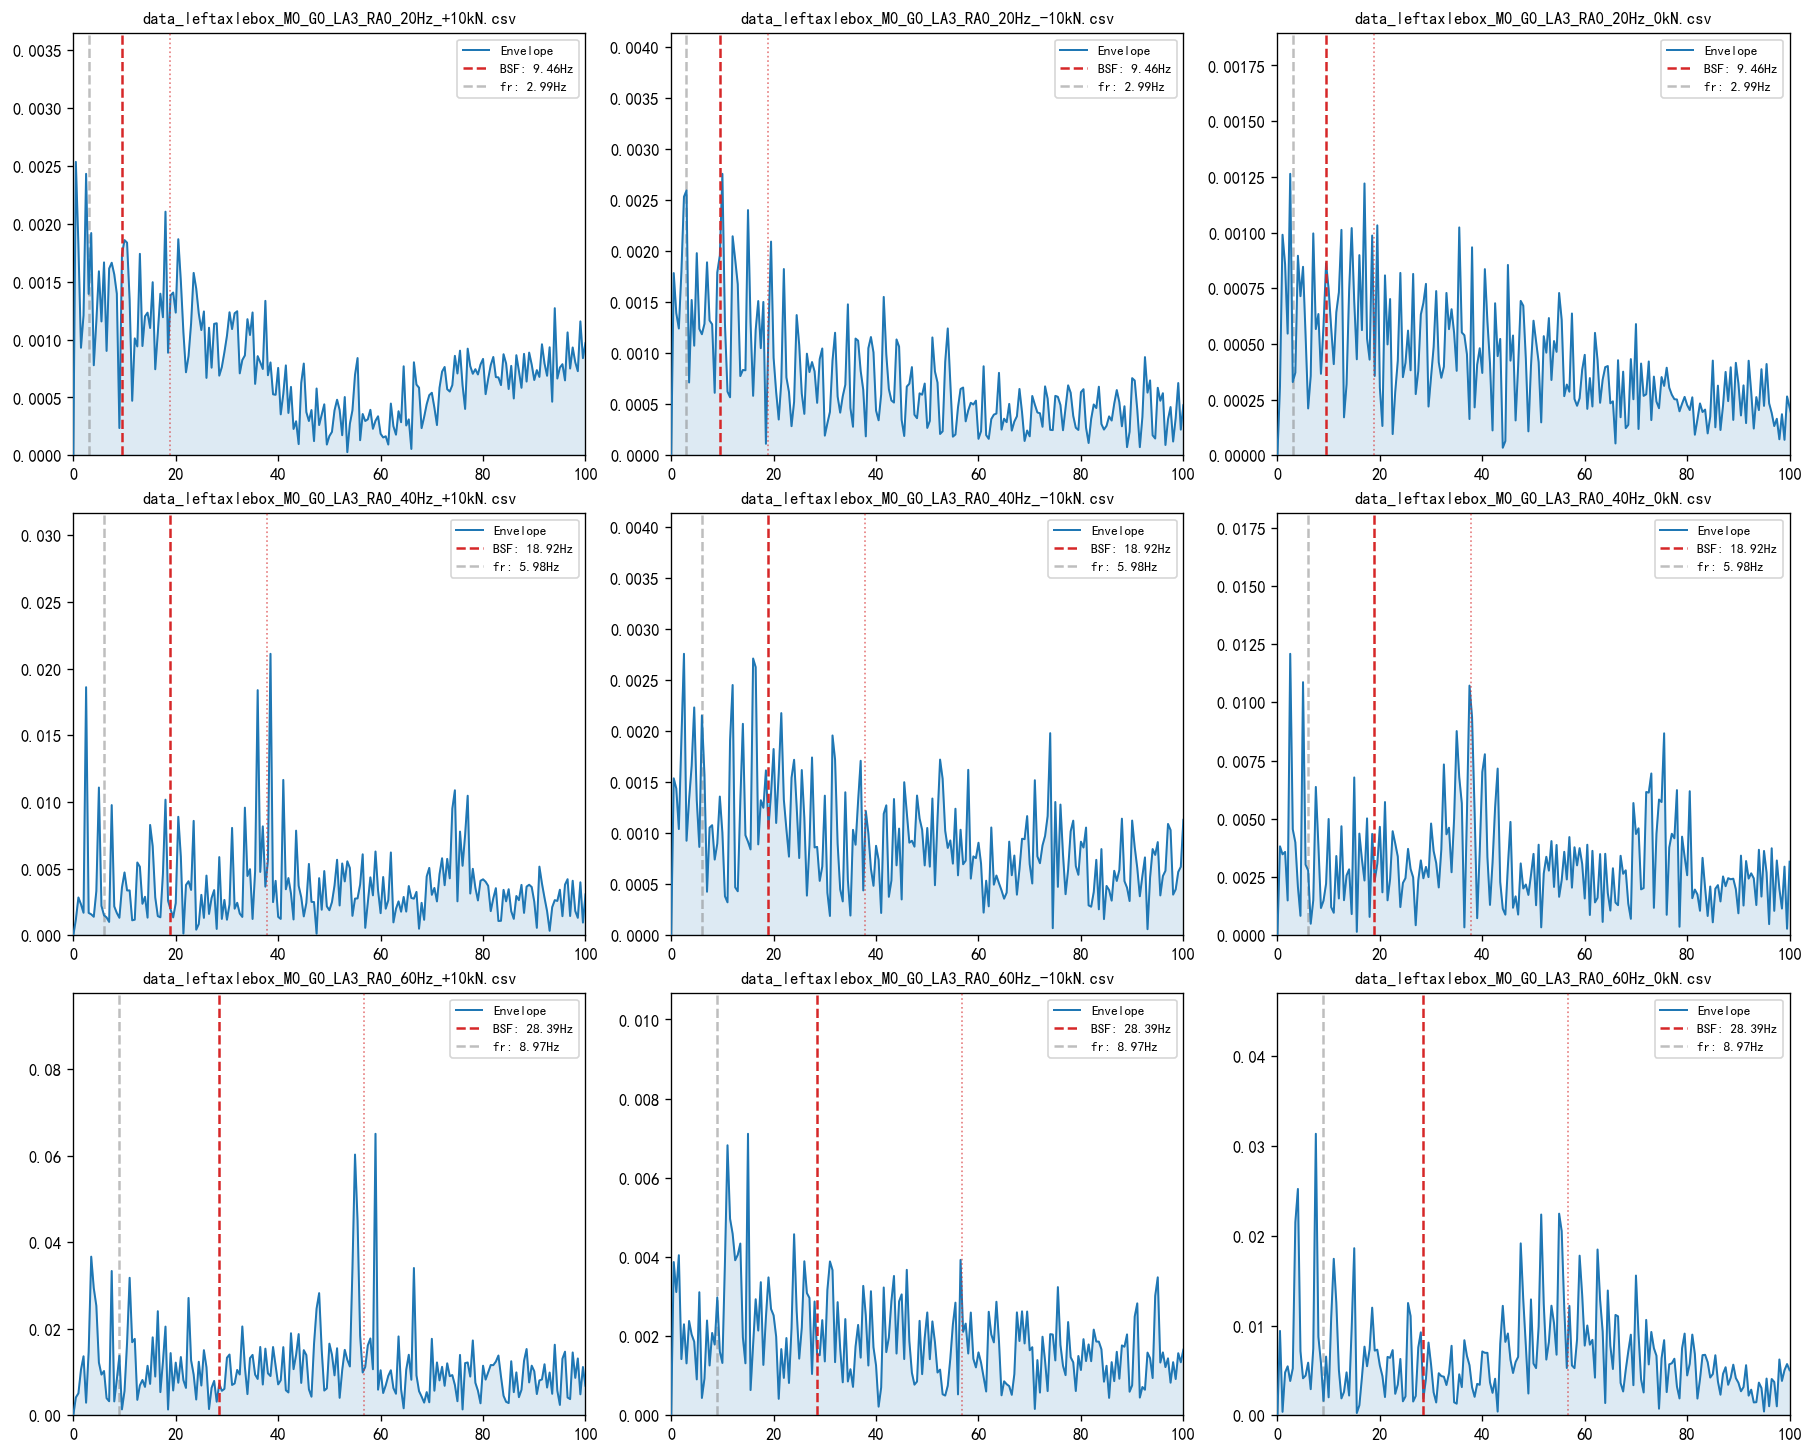

Processed: data_leftaxlebox_M0_G0_LA1_RA0_20Hz_+10kN.csv
Processed: data_leftaxlebox_M0_G0_LA1_RA0_20Hz_-10kN.csv
Processed: data_leftaxlebox_M0_G0_LA1_RA0_20Hz_0kN.csv
Processed: data_leftaxlebox_M0_G0_LA1_RA0_40Hz_+10kN.csv
Processed: data_leftaxlebox_M0_G0_LA1_RA0_40Hz_-10kN.csv
Processed: data_leftaxlebox_M0_G0_LA1_RA0_40Hz_0kN.csv
Processed: data_leftaxlebox_M0_G0_LA1_RA0_60Hz_+10kN.csv
Processed: data_leftaxlebox_M0_G0_LA1_RA0_60Hz_-10kN.csv
Processed: data_leftaxlebox_M0_G0_LA1_RA0_60Hz_0kN.csv


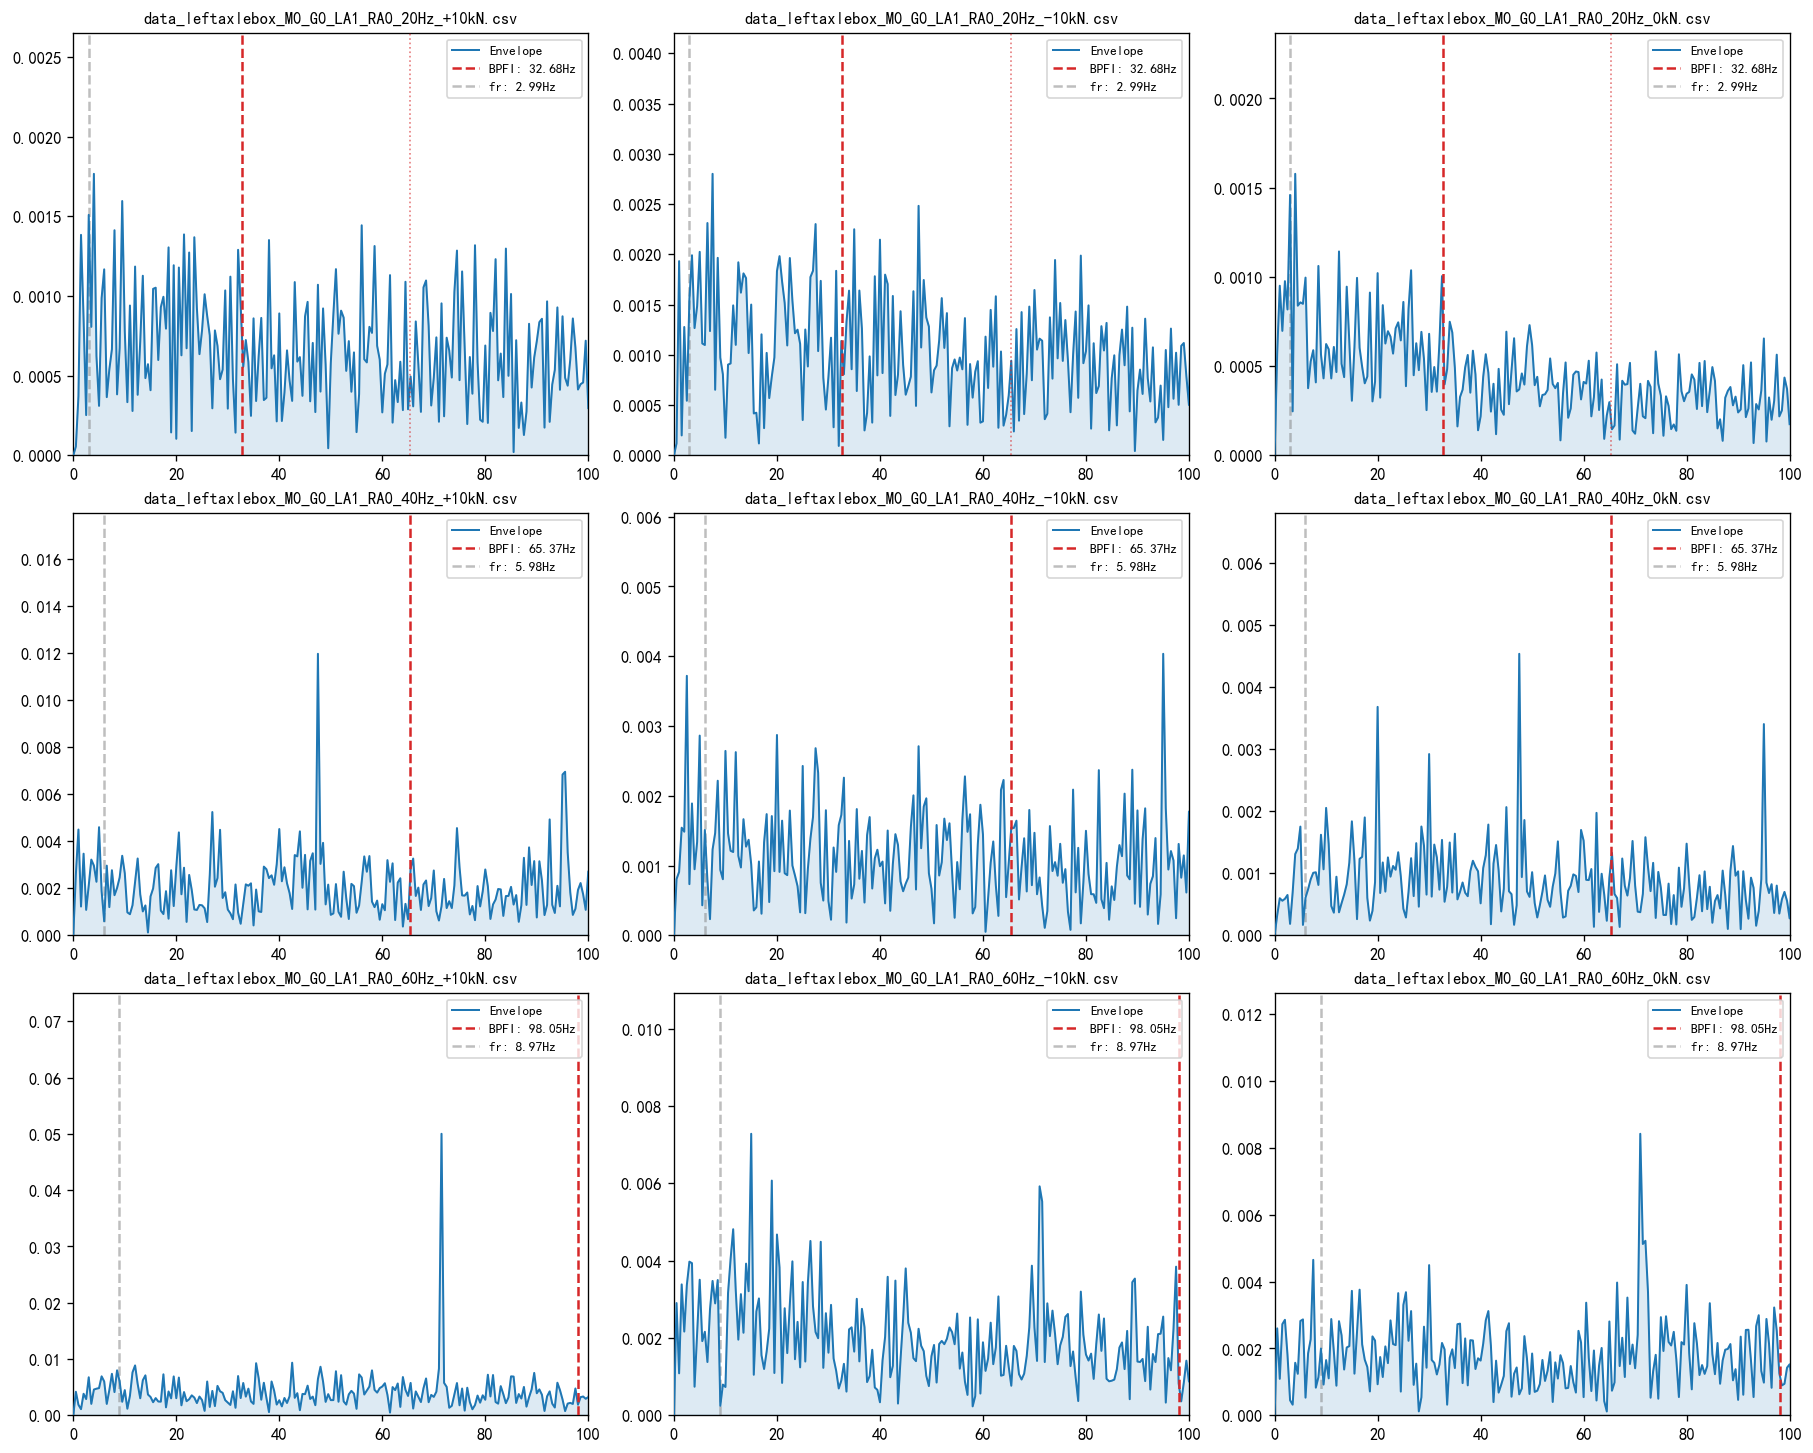

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import fftpack
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pylab import mpl
from scipy import signal
from scipy.linalg import toeplitz
from fast_kurtogram import Fast_Kurtogram  # 确保此模块在同一目录下
import numpy as np
from scipy import signal as scipy_signal
from scipy.linalg import toeplitz


class BearingAnalyzer:
    def __init__(self, fs=25600, xlim=100):
        """
        初始化分析器
        :param fs: 采样频率
        :param xlim: 频谱图显示的频率上限
        """
        self.fs = fs
        self.xlim = xlim
        # 轴承几何常数 (根据 BJTU 提供的 107/16 传动比计算)
        self.ratio = 107 / 16
        self.coeffs = {
            'BPFO': 8.071,  # 外圈故障系数
            'BPFI': 10.929,  # 内圈故障系数
            'BSF': 3.164  # 滚动体故障系数
        }
    def get_envelope(self, data, max_points=128000):
        """
        基于 AR预白化 + Fast Kurtogram 的包络谱提取
        保持原有输入输出接口不变
        """
        # 1. 截断数据
        raw_signal = data[:max_points]
        
        # ==========================================
        # 2. AR 预白化 (消除齿轮、工频等确定性干扰)
        # ==========================================
        order = 30
        # 计算自相关
        r = np.correlate(raw_signal, raw_signal, mode='full')[len(raw_signal)-1 : len(raw_signal)+order]
        
        # 求解 Yule-Walker 方程 (Toeplitz 矩阵)
        try:
            R = toeplitz(r[:-1])
            R += np.eye(order) * 1e-9 # 正则化防止奇异
            a = np.linalg.solve(R, -r[1:])
            ar_coeffs = np.concatenate(([1], a))
            # 滤波得到残差 (白化后的信号)
            whitened_signal = scipy_signal.lfilter(ar_coeffs, [1], raw_signal)
        except:
            # 失败则退回原信号，防止程序崩溃
            whitened_signal = raw_signal
            print("⚠️ AR预白化未收敛，使用原始信号继续...")
    
        # ==========================================
        # 3. Fast Kurtogram (寻找共振解调频带)
        # ==========================================
        # 假设类的初始化(__init__)中已经定义了 self.fs
        Kwav, Level_w, freq_w, filtered_c_signal, f_low, f_high = Fast_Kurtogram(
            whitened_signal, nlevel=4, Fs=self.fs, verbose=False
        )
        # print(f"🔍 Kurtogram 锁定频带: {f_low:.1f} - {f_high:.1f} Hz")
        
        # ==========================================
        # 4. 包络谱分析 (与原代码格式对齐)
        # ==========================================
        # 提取复包络信号的模
        at = np.abs(filtered_c_signal)
        # 去直流
        at = at - np.mean(at)
    
        # FFT 及 幅度归一化 (保留了你原来的逻辑)
        n = len(at)
        am = np.abs(np.fft.fft(at))
        am = (am / n) * 2
    
        # 计算有效采样率
        # 注意：Fast Kurtogram 滤波时可能会对信号进行降采样(Decimation)
        # 所以这里的实际采样率需按信号长度比例缩放，否则频率轴会对不齐！
        effective_fs = self.fs / (len(raw_signal) / len(filtered_c_signal))
    
        # 取正半轴
        half_n = n // 2
        freq = np.fft.fftfreq(n, d=1 / effective_fs)[:half_n]
        amp = am[:half_n]
        
        return freq, amp
            
    
    def plot_diagnostic(self, ax, freq, amp, motor_f, title, fault_type='BSF'):
            """绘图与理论频率标注"""
            fr = motor_f / self.ratio  # 计算轴转频
    
            # 绘制包络谱
            ax.plot(freq, amp, color='#1f77b4', lw=1.2, label='Envelope', zorder=3)
            ax.fill_between(freq, amp, color='#1f77b4', alpha=0.15)
    
            # 标注故障特征频率 (1倍频与2倍频)
            if fault_type in self.coeffs:
                f_fault = fr * self.coeffs[fault_type]
                label_name = f"{fault_type}: {f_fault:.2f}Hz"
                ax.axvline(f_fault, color='#d62728', ls='--', lw=1.5, label=label_name, zorder=4)
                ax.axvline(f_fault * 2, color='#d62728', ls=':', lw=1, alpha=0.6, zorder=4)
    
            # 标注转频
            ax.axvline(fr, color='#7f7f7f', ls='--', alpha=0.5, label=f'fr: {fr:.2f}Hz')
    
            # 细节优化
            ax.set_title(title, fontsize=10, fontweight='bold')
            ax.set_xlim(0, self.xlim)
            # 自动调整Y轴刻度 (避开1Hz以内的低频干扰)
            valid_idx = freq > 1
            if any(valid_idx):
                ax.set_ylim(0, np.max(amp[valid_idx]) * 1.5)
            ax.legend(loc='upper right', fontsize=8)
    
    def process_folder(self, folder_path, fault_type='BSF'):
            """批量处理文件夹内的所有 CSV 文件"""
            files = sorted([f for f in os.listdir(folder_path) if f.endswith('.csv')])
            cols = 3
            rows = (len(files) + cols - 1) // cols
            fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows), constrained_layout=True)
            axes = axes.flatten()
            for i, file_name in enumerate(files):
                # 1. 自动从文件名解析频率 (假设格式为 ..._40Hz_...)
                motor_f = float(file_name.split('Hz')[0].split('_')[-1])
                df = pd.read_csv(os.path.join(folder_path, file_name))
                data = df.iloc[:, 0].values
                # 3. 计算与绘图
                f, a = self.get_envelope(data)
                self.plot_diagnostic(axes[i], f, a, motor_f, file_name, fault_type)
                print(f"Processed: {file_name}")
    
            # 隐藏多余子图
            for j in range(i + 1, len(axes)):
                axes[j].axis('off')
    
            plt.show()


# --- 使用示例 ---
analyzer = BearingAnalyzer(fs=64000, xlim=100)
analyzer.process_folder('../数据集/BJTU/滚动体', fault_type='BSF')
analyzer = BearingAnalyzer(fs=64000, xlim=100)
analyzer.process_folder('../数据集/BJTU/内圈', fault_type='BPFI')
